### Dataset

https://www.kaggle.com/datasets/jacksondivakarr/online-shopping-dataset

- **CustomerID:** Unique identifier for each customer.
- **Gender:** Gender of the customer (e.g., Male, Female).
- **Location:** Location or address information of the customer.
- **Tenure_Months:** Number of months the customer has been associated with the platform.
- **Transaction_ID:** Unique identifier for each transaction.
- **Transaction_Date:** Date of the transaction.
- **Product_SKU:**  Stock Keeping Unit (SKU) identifier for the product.
- **Product_Description:** Description of the product.
- **Product_Category:** Category to which the product belongs.
- **Quantity:** Quantity of the product purchased in the transaction.
- **Avg_Price:** Average price of the product.
- **Delivery_Charges:** Charges associated with the delivery of the product.
- **Coupon_Status:** Status of the coupon associated with the transaction.
- **GST:** Goods and Services Tax associated with the transaction.
- **Date:** Date of the transaction (potentially redundant with Transaction_Date).
- **Offline_Spend:** Amount spent offline by the customer.
- **Online_Spend:** Amount spent online by the customer.
- **Month:** Month of the transaction.
- **Coupon_Code:** Code associated with a coupon, if applicable.
- **Discount_pct:** Percentage of discount applied to the transaction.

### Problem Definition

1) **Objective:**
> Memahami pola perilaku pelanggan dalam berbelanja online, mengidentifikasi faktor-faktor yang memengaruhi nilai transaksi, serta mengevaluasi peran diskon dan kupon terhadap pengeluaran pelanggan. Analisis ini diharapkan dapat memberikan insight yang berguna bagi perusahaan dalam meningkatkan strategi pemasaran, loyalitas pelanggan, dan optimalisasi pendapatan.

2) **Questions:**
> - Bagaimana distribusi dan perbandingan pengeluaran pelanggan antara belanja online dan offline?
> - Apakah lama berlangganan pelanggan (Tenure_Months) berpengaruh terhadap total pengeluaran dan frekuensi transaksi?
> - Kategori produk apa yang paling banyak dibeli dan memberikan kontribusi pendapatan terbesar?
> - Apakah terdapat hubungan antara harga rata-rata produk (Avg_Price) dengan jumlah pembelian (Quantity)?
> - Bagaimana pengaruh penggunaan kupon (Coupon_Status) terhadap nilai transaksi dan jumlah produk yang dibeli?
> - Seberapa besar pengaruh persentase diskon (Discount_pct) terhadap peningkatan pengeluaran pelanggan?
> - Apakah terdapat perbedaan perilaku belanja berdasarkan gender pelanggan?
> - Bagaimana pola transaksi dan pengeluaran pelanggan berdasarkan waktu (bulan)?
> - Seberapa besar kontribusi biaya tambahan (Delivery_Charges dan GST) terhadap total nilai transaksi?

### Data Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import chardet
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import f_oneway, ttest_ind

import os
for dirname, _, filenames in os.walk("./dataset/"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./dataset/file.csv
./dataset/file.xlsx


In [2]:
with open("./dataset/file.csv", "rb") as f:
    print(chardet.detect(f.read()))

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [3]:
df = pd.read_csv("./dataset/file.csv")

In [4]:
df

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Avg_Price,Delivery_Charges,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct
0,0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
1,1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
2,2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,122.77,6.5,Not Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
3,3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,81.50,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
4,4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52950,52950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Gift Cards,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,GC20,20.0
52951,52951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Notebooks & Journals,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,NJ20,20.0
52952,52952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Android,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,AND10,10.0
52953,52953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Android,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,AND20,20.0


### Preprocessing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52955 entries, 0 to 52954
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           52955 non-null  int64  
 1   CustomerID           52924 non-null  float64
 2   Gender               52924 non-null  object 
 3   Location             52924 non-null  object 
 4   Tenure_Months        52924 non-null  float64
 5   Transaction_ID       52924 non-null  float64
 6   Transaction_Date     52924 non-null  object 
 7   Product_SKU          52924 non-null  object 
 8   Product_Description  52924 non-null  object 
 9   Product_Category     52955 non-null  object 
 10  Quantity             52924 non-null  float64
 11  Avg_Price            52924 non-null  float64
 12  Delivery_Charges     52924 non-null  float64
 13  Coupon_Status        52924 non-null  object 
 14  GST                  52924 non-null  float64
 15  Date                 52924 non-null 

In [6]:
df.isnull().sum()

Unnamed: 0               0
CustomerID              31
Gender                  31
Location                31
Tenure_Months           31
Transaction_ID          31
Transaction_Date        31
Product_SKU             31
Product_Description     31
Product_Category         0
Quantity                31
Avg_Price               31
Delivery_Charges        31
Coupon_Status           31
GST                     31
Date                    31
Offline_Spend           31
Online_Spend            31
Month                    0
Coupon_Code            400
Discount_pct           400
dtype: int64

In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
df = df.dropna(
    subset=[
        "CustomerID", "Gender", "Location", "Tenure_Months", "Transaction_ID", "Transaction_Date", "Product_SKU", "Product_Description", "Quantity", "Avg_Price",
        "Delivery_Charges", "Coupon_Status", "GST", "Date", "Offline_Spend", "Online_Spend"
    ]
)

In [9]:
df["Coupon_Code"] = df["Coupon_Code"].fillna("No Coupon")

In [10]:
df["Discount_pct"] = df["Discount_pct"].fillna(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,CustomerID,Tenure_Months,Transaction_ID,Quantity,Avg_Price,Delivery_Charges,GST,Offline_Spend,Online_Spend,Month,Discount_pct
count,52924.00000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000
mean,15346.70981,26.127995,32409.825675,4.497638,52.237646,10.517630,0.137462,2830.914141,1893.109119,6.652388,19.802358
std,1766.55602,13.478285,8648.668977,20.104711,64.006882,19.475613,0.045825,936.154247,807.014092,3.333364,8.278878
min,12346.00000,2.000000,16679.000000,1.000000,0.390000,0.000000,0.050000,500.000000,320.250000,1.000000,0.000000
25%,13869.00000,15.000000,25384.000000,1.000000,5.700000,6.000000,0.100000,2500.000000,1252.630000,4.000000,10.000000
50%,15311.00000,27.000000,32625.500000,1.000000,16.990000,6.000000,0.180000,3000.000000,1837.870000,7.000000,20.000000
75%,16996.25000,37.000000,39126.250000,2.000000,102.130000,6.500000,0.180000,3500.000000,2425.350000,9.000000,30.000000
max,18283.00000,50.000000,48497.000000,900.000000,355.740000,521.360000,0.180000,5000.000000,4556.930000,12.000000,30.000000


In [13]:
num_cols = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'CustomerID': 0,
 'Tenure_Months': 0,
 'Transaction_ID': 0,
 'Quantity': 8284,
 'Avg_Price': 728,
 'Delivery_Charges': 10243,
 'GST': 0,
 'Offline_Spend': 1954,
 'Online_Spend': 265,
 'Month': 0,
 'Discount_pct': 0}

> Perlu diingat, bahwa outlier bukan berarti data buruk. Terutama dalam data transaksi seperti jual beli. Hal ini termasuk normal.

In [14]:
df.describe(include="object").T

,count,unique,top,freq
Gender,52924,2,F,33007
Location,52924,5,Chicago,18380
Transaction_Date,52924,365,2019-11-27,335
Product_SKU,52924,1145,GGOENEBJ079499,3511
Product_Description,52924,404,Nest Learning Thermostat 3rd Gen-USA - Stainle...,3511
Product_Category,52924,20,Apparel,18126
Coupon_Status,52924,3,Clicked,26926
Date,52924,365,11/27/2019,335
Coupon_Code,52924,46,SALE20,6373


### EDA

#### Bagaimana distribusi dan perbandingan pengeluaran pelanggan antara belanja online dan offline?

In [15]:
df[["Online_Spend", "Offline_Spend"]].describe()

,Online_Spend,Offline_Spend
count,52924.000000,52924.000000
mean,1893.109119,2830.914141
std,807.014092,936.154247
min,320.250000,500.000000
25%,1252.630000,2500.000000
50%,1837.870000,3000.000000
75%,2425.350000,3500.000000
max,4556.930000,5000.000000


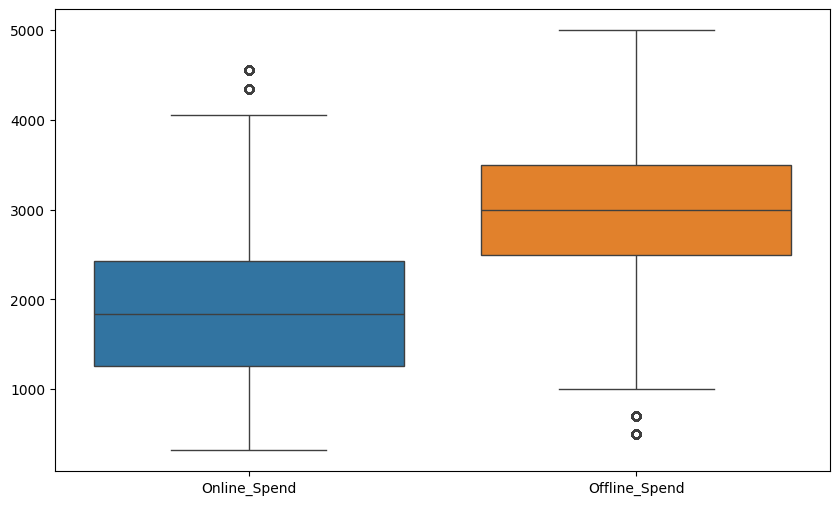

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(
    df[["Online_Spend", "Offline_Spend"]]
)
plt.show()

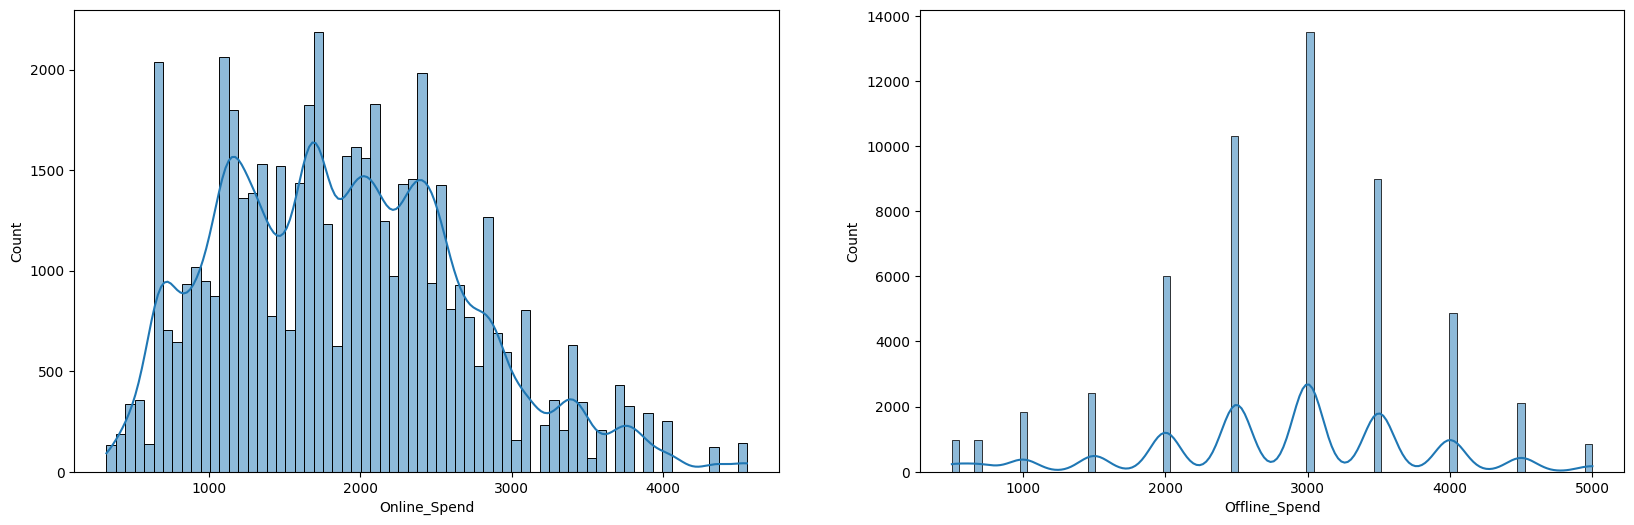

In [17]:
plt.figure(figsize=(20,6))

plt.subplot(1, 2, 1)
sns.histplot(
    data=df,
    x="Online_Spend",
    kde=True
)

plt.subplot(1, 2, 2)
sns.histplot(
    data=df,
    x="Offline_Spend",
    kde=True
)

plt.show()

In [18]:
print("Total Online Spend:", sum(df["Online_Spend"]))
print("Total Offline Spend:", sum(df["Offline_Spend"]))

Total Online Spend: 100190907.01999627
Total Offline Spend: 149823300.0


#### Apakah lama berlangganan pelanggan (Tenure_Months) berpengaruh terhadap total pengeluaran dan frekuensi transaksi?

In [19]:
df["Tenure_Months"].describe()

count    52924.000000
mean        26.127995
std         13.478285
min          2.000000
25%         15.000000
50%         27.000000
75%         37.000000
max         50.000000
Name: Tenure_Months, dtype: float64

In [20]:
df[["Avg_Price", "Quantity"]].describe()

,Avg_Price,Quantity
count,52924.000000,52924.000000
mean,52.237646,4.497638
std,64.006882,20.104711
min,0.390000,1.000000
25%,5.700000,1.000000
50%,16.990000,1.000000
75%,102.130000,2.000000
max,355.740000,900.000000


In [21]:
df["Transaction_value"] = df["Avg_Price"] * df["Quantity"]

In [22]:
df["Transaction_value"].describe()

count    52924.000000
mean        88.254754
std        163.993178
min          0.400000
25%         11.960000
50%         30.390000
75%        121.300000
max      10512.390000
Name: Transaction_value, dtype: float64

> Ingat, target disini adalah pelanggan. Karena pada data ini 1 baris = 1 transaksi, dimana bisa saja 1 pelanggan melakukan banyak transaksi.

In [23]:
customer_order = df.groupby("CustomerID").agg(
    Total_Spend = ("Transaction_value", "sum"), # total spend
    Customer_frequency = ("Transaction_ID", "nunique"), # jumlah nilai unik
    Tenure_Months = ("Tenure_Months", "first")  # mengambil nilai pertama
).reset_index()

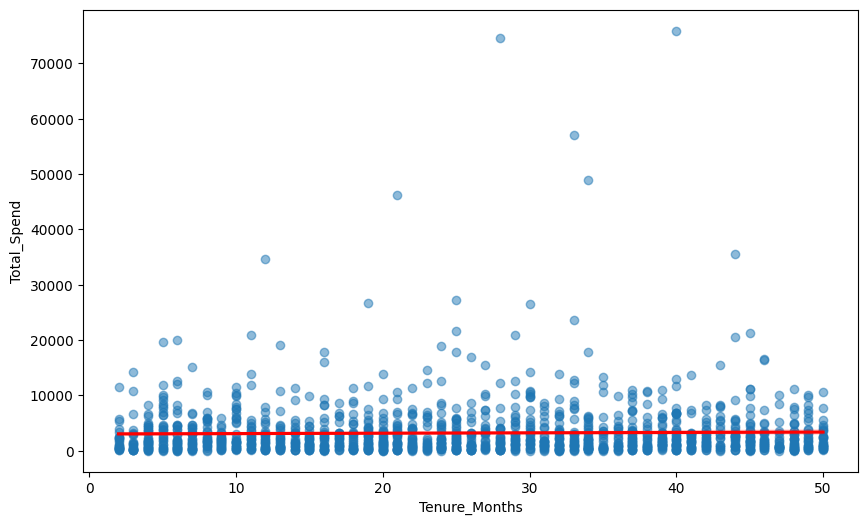

In [24]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=customer_order,
    x="Tenure_Months",
    y="Total_Spend",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.show()

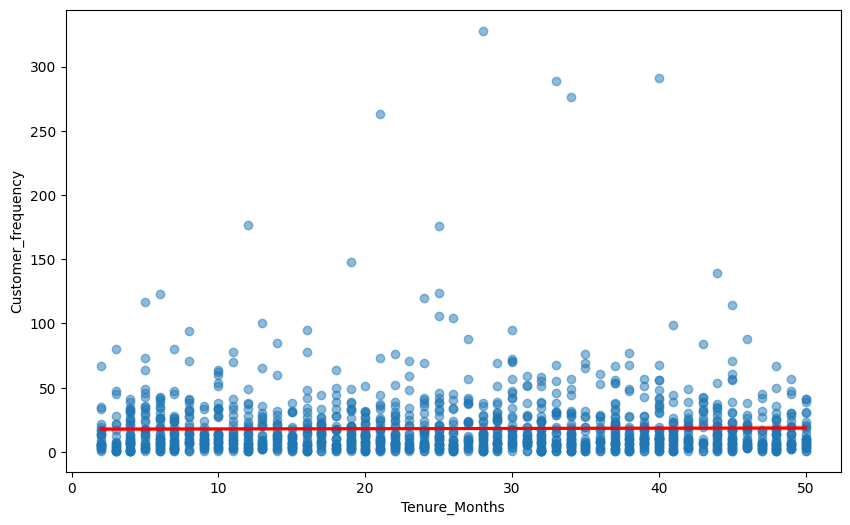

In [25]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=customer_order,
    x="Tenure_Months",
    y="Customer_frequency",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.show()

In [26]:
df[["Tenure_Months", "Transaction_value", "Transaction_ID"]].corr(method="spearman")

,Tenure_Months,Transaction_value,Transaction_ID
Tenure_Months,1.000000,-0.002378,0.021860
Transaction_value,-0.002378,1.000000,0.016727
Transaction_ID,0.021860,0.016727,1.000000


In [27]:
bins = [0, 6, 12, 24, 60]
labels = ["New", "Growing", "Loyal", "Very Loyal"]

df["Tenure_Group"] = pd.cut(df["Tenure_Months"], bins=bins, labels=labels)

In [28]:
tenure_cust = df.groupby("Tenure_Group")["Transaction_value"].mean().sort_values(ascending=False).reset_index()
tenure_cust

,Tenure_Group,Transaction_value
0,Very Loyal,89.306311
1,Growing,88.821261
2,New,87.862366
3,Loyal,85.596413


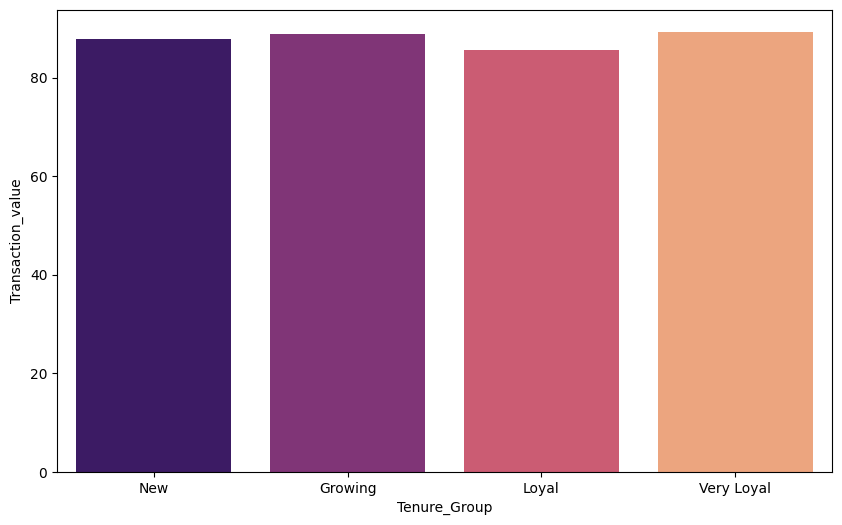

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=tenure_cust,
    x="Tenure_Group",
    y="Transaction_value",
    palette="magma"
)

plt.show()

#### Kategori produk apa yang paling banyak dibeli dan memberikan kontribusi pendapatan terbesar?

In [30]:
df["Product_Category"].describe()

count       52924
unique         20
top       Apparel
freq        18126
Name: Product_Category, dtype: object

Paling sering dibeli

In [31]:
df["Product_Category"].value_counts()

Product_Category
Apparel                 18126
Nest-USA                14013
Office                   6513
Drinkware                3483
Lifestyle                3092
Nest                     2198
Bags                     1882
Headgear                  771
Notebooks & Journals      749
Waze                      554
Nest-Canada               317
Bottles                   268
Accessories               234
Fun                       160
Gift Cards                159
Housewares                122
Google                    105
Backpacks                  89
More Bags                  46
Android                    43
Name: count, dtype: int64

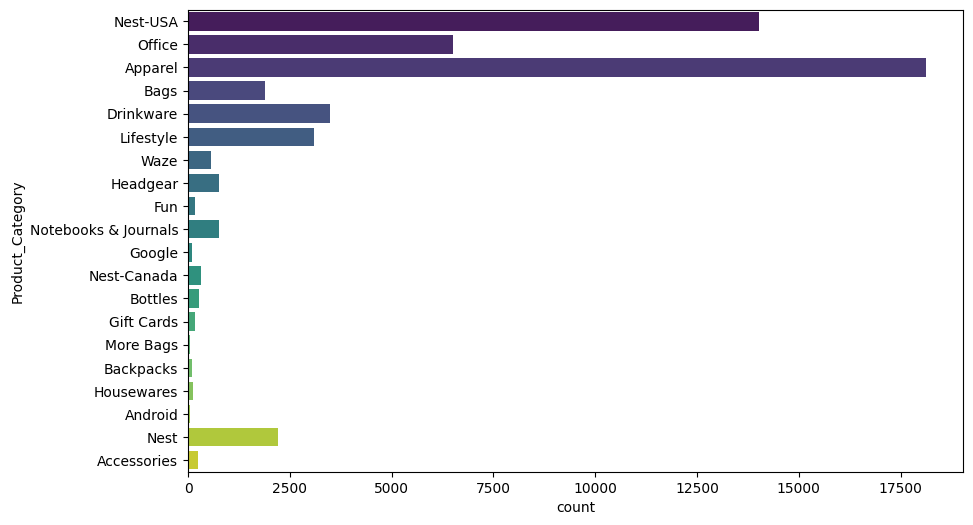

In [32]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="Product_Category",
    palette="viridis"
)
plt.show()

Produk paling banyak dibeli

In [33]:
category_jumlah_quantity = df.groupby("Product_Category")["Quantity"].sum().sort_values(ascending=False).reset_index()
category_jumlah_quantity

,Product_Category,Quantity
0,Office,88383.0
1,Apparel,32438.0
2,Drinkware,30501.0
3,Lifestyle,24881.0
4,Nest-USA,21430.0
5,Bags,15273.0
6,Notebooks & Journals,9556.0
7,Headgear,3533.0
8,Nest,2837.0
9,Housewares,2484.0


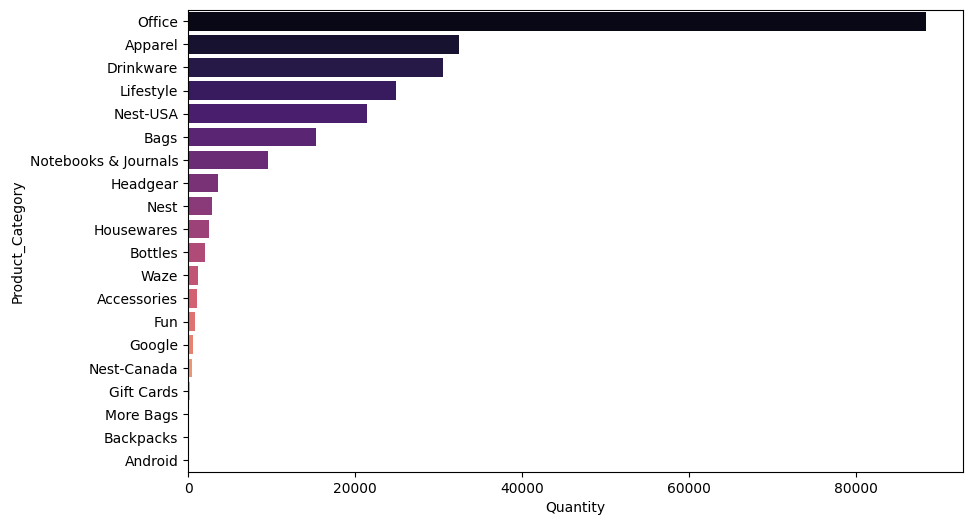

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=category_jumlah_quantity,
    x="Quantity",
    y="Product_Category",
    palette="magma"
)

plt.show()

Produk dengan jumlah pendapatan

In [35]:
category_total_revenue = df.groupby("Product_Category")["Transaction_value"].sum().sort_values(ascending=False).reset_index()
category_total_revenue

,Product_Category,Transaction_value
0,Nest-USA,2554202.39
1,Apparel,591145.80
2,Nest,518193.50
3,Office,276794.40
4,Drinkware,200707.83
5,Bags,151314.43
6,Notebooks & Journals,107085.96
7,Lifestyle,74385.70
8,Nest-Canada,70910.40
9,Headgear,53471.44


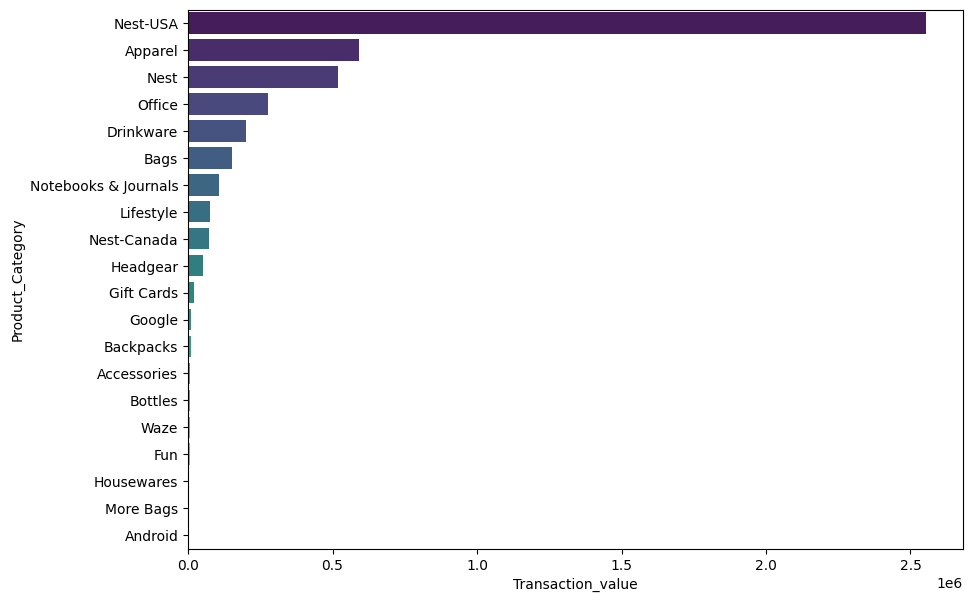

In [36]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=category_total_revenue,
    x="Transaction_value",
    y="Product_Category",
    palette="viridis"
)
plt.show()

**Insight:**
> Hasil analisis menunjukkan bahwa kategori Apparel merupakan kategori yang paling banyak dibeli berdasarkan jumlah transaksi. Namun, kategori dengan kontribusi pendapatan terbesar adalah Nest-USA, yang meskipun memiliki frekuensi pembelian lebih rendah dibandingkan Apparel, menghasilkan nilai transaksi yang jauh lebih tinggi. Hal ini menunjukkan bahwa frekuensi pembelian yang tinggi tidak selalu berbanding lurus dengan kontribusi pendapatan.

kurang ini insight nya..

#### Apakah terdapat hubungan antara harga rata-rata produk (Avg_Price) dengan jumlah pembelian (Quantity)?

In [37]:
df[["Avg_Price", "Quantity"]].corr()

,Avg_Price,Quantity
Avg_Price,1.000000,-0.113996
Quantity,-0.113996,1.000000


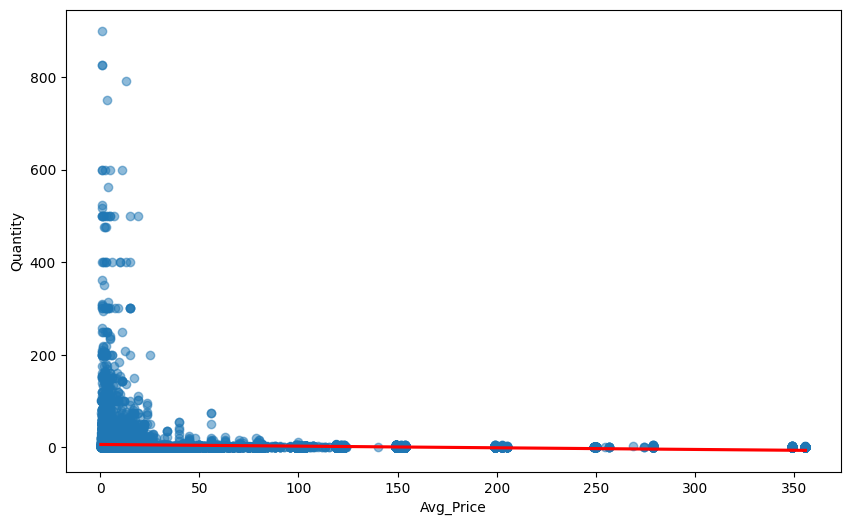

In [38]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Avg_Price",
    y="Quantity",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)   

plt.show()

In [39]:
import statsmodels.api as sm

X = df["Avg_Price"]
y = df["Quantity"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     696.8
Date:                Sat, 28 Feb 2026   Prob (F-statistic):          1.47e-152
Time:                        11:44:18   Log-Likelihood:            -2.3357e+05
No. Observations:               52924   AIC:                         4.671e+05
Df Residuals:                   52922   BIC:                         4.672e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.3681      0.112     56.823      0.0

metode ini sama dengan linear regression, tapi lebih menekankan pada statistik.

**Insight:**
> Berdasarkan nilai korelasi sebesar −0.11, hubungan antara harga rata-rata produk (Avg_Price) dan jumlah pembelian (Quantity) tergolong sangat lemah dan bersifat negatif. Hal ini menunjukkan bahwa secara umum harga produk tidak memiliki pengaruh yang signifikan terhadap jumlah pembelian, kemungkinan karena variasi perilaku konsumen antar kategori produk serta faktor lain seperti kebutuhan, promosi, dan preferensi pelanggan.

#### Bagaimana pengaruh penggunaan kupon (Coupon_Status) terhadap nilai transaksi dan jumlah produk yang dibeli?

In [40]:
df["Coupon_Status"].describe()

count       52924
unique          3
top       Clicked
freq        26926
Name: Coupon_Status, dtype: object

In [41]:
df.groupby("Coupon_Status")["Transaction_value"].describe().T

Coupon_Status,Clicked,Not Used,Used
count,26926.000000,8094.000000,17904.000000
mean,88.288890,90.525064,87.177061
std,155.035858,173.384624,172.507097
min,0.400000,0.400000,0.400000
25%,12.000000,11.950000,11.750000
50%,31.170000,30.390000,30.000000
75%,120.000000,121.300000,121.300000
max,7495.000000,5996.000000,10512.390000


In [42]:
df.groupby("Coupon_Status")["Quantity"].describe().T

Coupon_Status,Clicked,Not Used,Used
count,26926.000000,8094.000000,17904.000000
mean,4.447746,4.383741,4.624162
std,19.029251,17.673551,22.561770
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000
max,600.000000,500.000000,900.000000


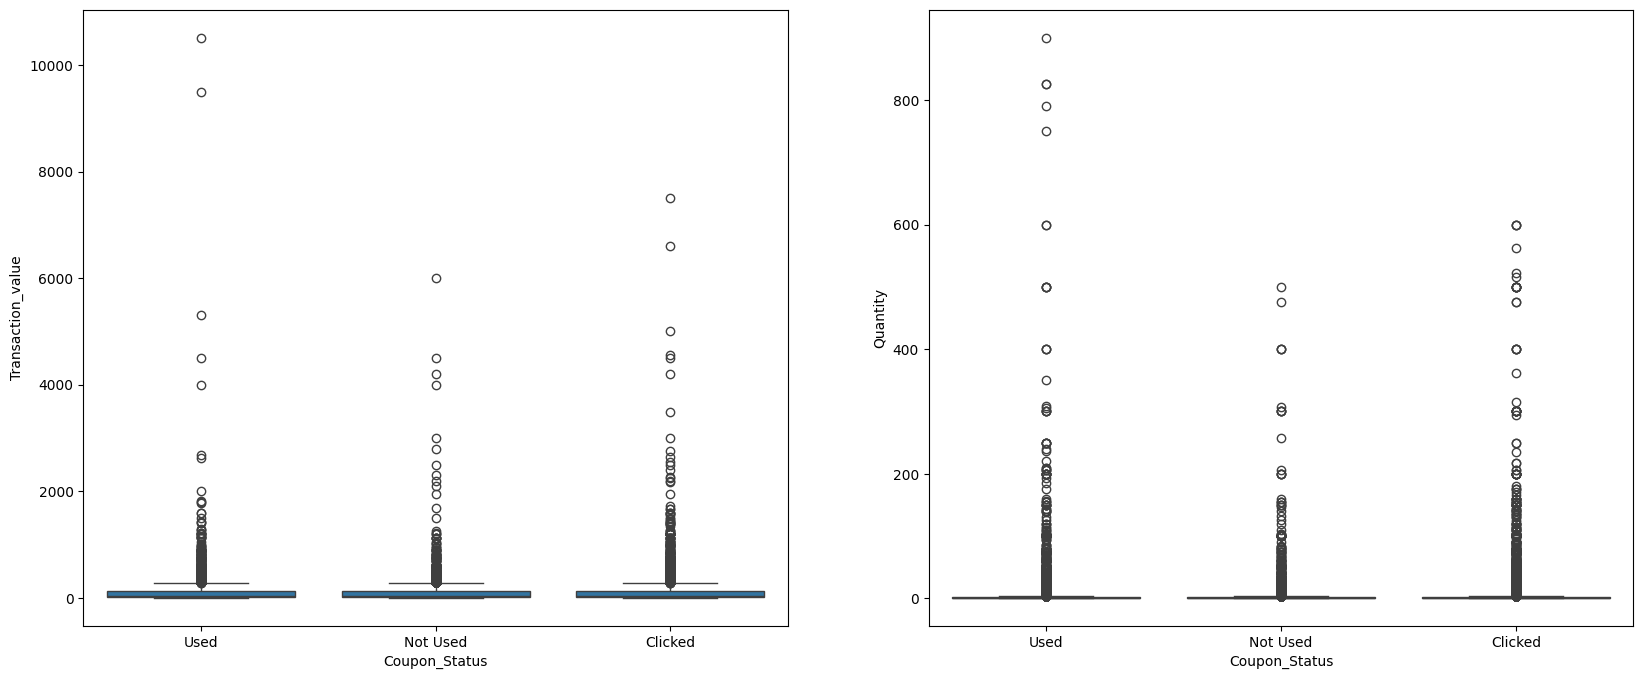

In [43]:
plt.figure(figsize=(20,8))

plt.subplot(1, 2, 1)
sns.boxplot(
    data=df,
    x="Coupon_Status",
    y="Transaction_value"
)

plt.subplot(1, 2, 2)
sns.boxplot(
    data=df,
    x="Coupon_Status",
    y="Quantity"
)

plt.show()

In [44]:
coupon_status_order = df.groupby("Coupon_Status")["Transaction_value"].mean().reset_index()

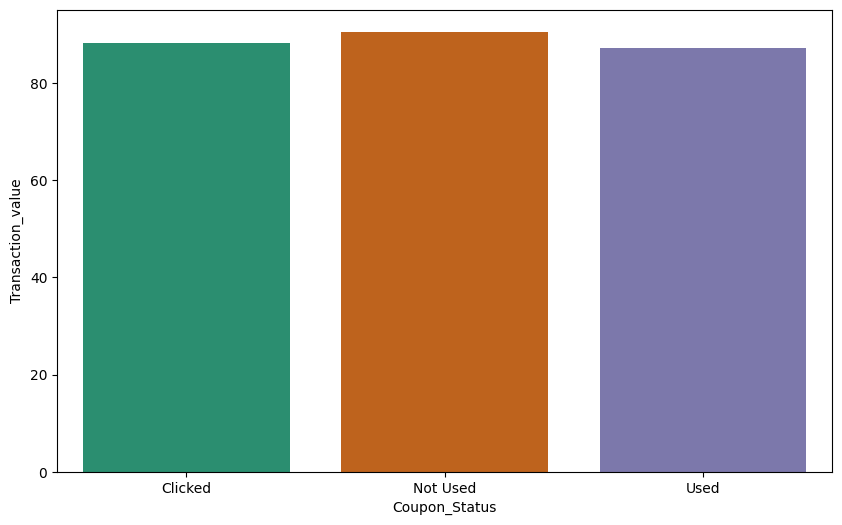

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=coupon_status_order,
    x="Coupon_Status",
    y="Transaction_value",
    palette="Dark2"
)
plt.show()

In [46]:
# uji pengaruh menggunakan f_oneway

groups = [
    group["Transaction_value"].values
    for name, group in df.groupby("Coupon_Status")
]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 1.1628130873897295
P-value: 0.31261354304660394


#### Seberapa besar pengaruh persentase diskon (Discount_pct) terhadap peningkatan pengeluaran pelanggan?

In [47]:
df["Discount_pct"].describe()

count    52924.000000
mean        19.802358
std          8.278878
min          0.000000
25%         10.000000
50%         20.000000
75%         30.000000
max         30.000000
Name: Discount_pct, dtype: float64

In [48]:
df[["Discount_pct", "Transaction_value"]].corr()

,Discount_pct,Transaction_value
Discount_pct,1.000000,0.001435
Transaction_value,0.001435,1.000000


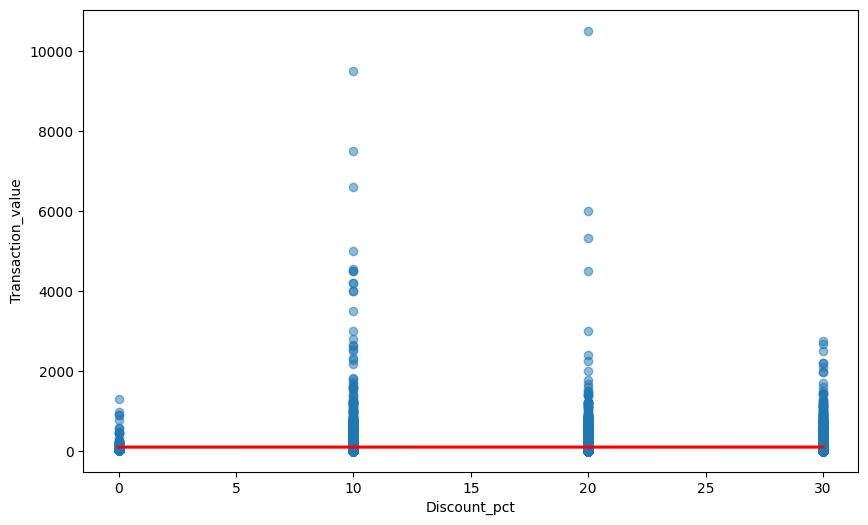

In [49]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x="Discount_pct",
    y="Transaction_value",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.show()

In [50]:
bins = [-1, 0, 10, 20, 30, 100]
labels = ["No Discount", "0-10%", "11-20%", "21-30%", ">30%"]

df["Discount_bucket"] = pd.cut(
    df["Discount_pct"],
    bins=bins,
    labels=labels
)

In [51]:
df["Discount_bucket"].value_counts()

Discount_bucket
11-20%         17830
0-10%          17470
21-30%         17224
No Discount      400
>30%               0
Name: count, dtype: int64

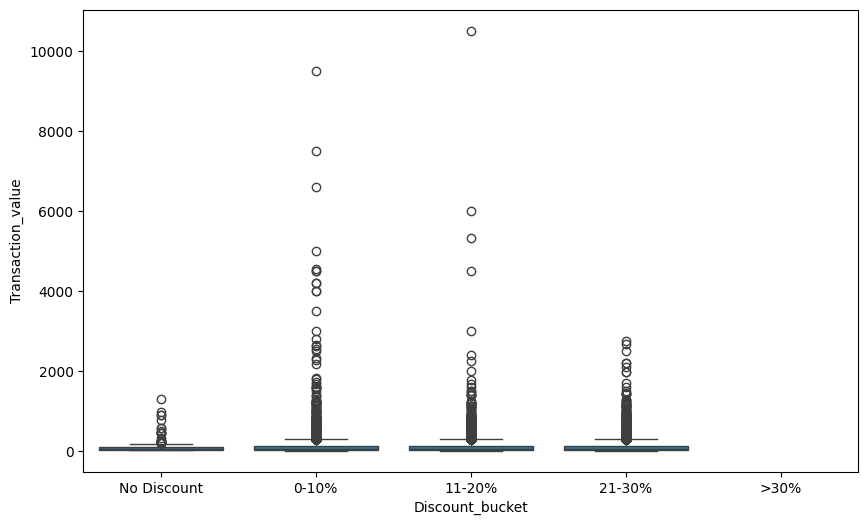

In [52]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="Discount_bucket",
    y="Transaction_value"
)
plt.show()

In [53]:
df.groupby("Discount_bucket")["Transaction_value"].describe().T

Discount_bucket,No Discount,0-10%,11-20%,21-30%,>30%
count,400.000000,17470.000000,17830.000000,17224.000000,0.0
mean,67.922825,90.182740,85.266916,89.864370,NaN
std,128.549593,194.213347,162.255627,129.308137,NaN
min,3.600000,0.400000,0.400000,0.410000,NaN
25%,11.452500,11.190000,11.190000,13.590000,NaN
50%,27.895000,30.000000,28.515000,35.000000,NaN
75%,79.990000,122.770000,119.000000,121.300000,NaN
max,1299.350000,9495.000000,10512.390000,2747.500000,NaN


In [54]:
discount_order = df.groupby("Discount_bucket")["Transaction_value"].agg(["count", "mean", "median"])
discount_order

,count,mean,median
Discount_bucket,,,
No Discount,400,67.922825,27.895
0-10%,17470,90.182740,30.000
11-20%,17830,85.266916,28.515
21-30%,17224,89.864370,35.000
>30%,0,NaN,NaN


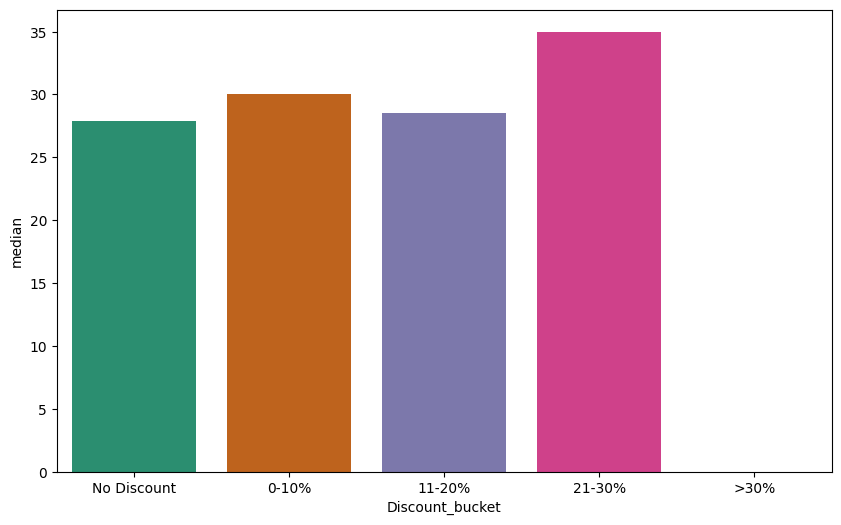

In [55]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=discount_order,
    x="Discount_bucket",
    y="median",
    palette="Dark2"
)

plt.show()

#### Apakah terdapat perbedaan perilaku belanja berdasarkan gender pelanggan?

In [56]:
df["Gender"].describe()

count     52924
unique        2
top           F
freq      33007
Name: Gender, dtype: object

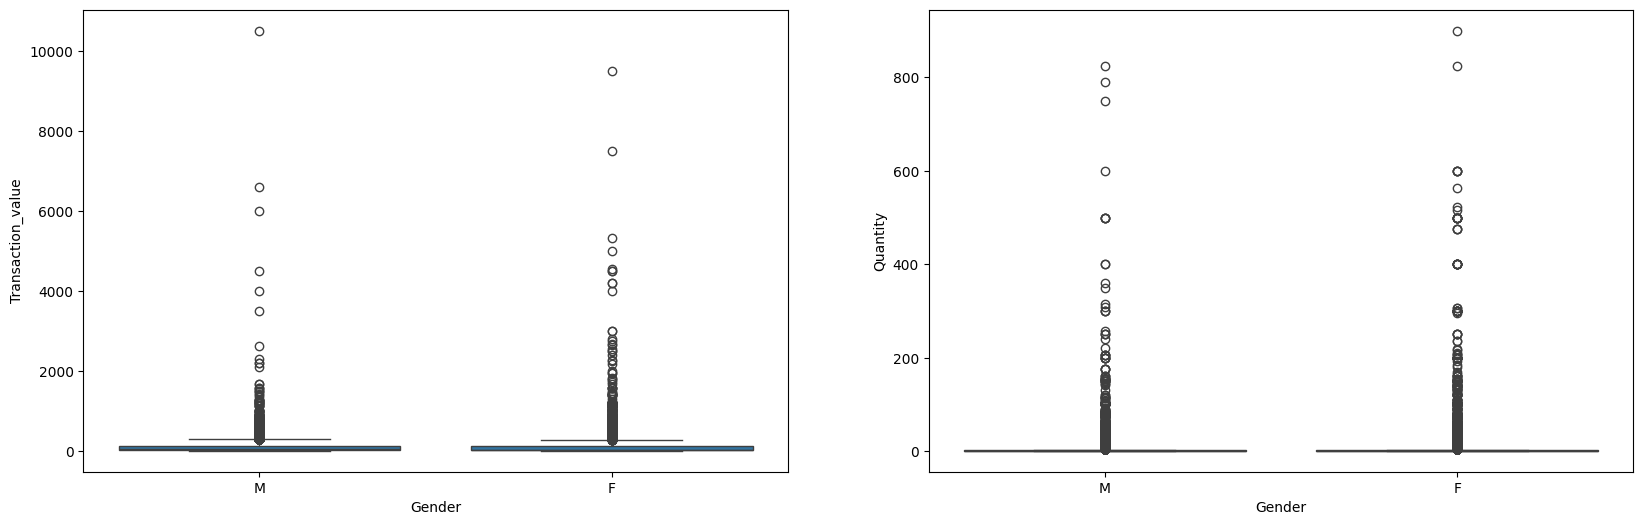

In [57]:
plt.figure(figsize=(20,6))

plt.subplot(1, 2, 1)
sns.boxplot(
    data=df,
    x="Gender",
    y="Transaction_value"
)

plt.subplot(1, 2, 2)
sns.boxplot(
    data=df,
    x="Gender",
    y="Quantity"
)
plt.show()

In [58]:
df.groupby("Gender")[["Transaction_value", "Quantity"]].describe().T

Gender                              F             M
Transaction_value count  33007.000000  19917.000000
                  mean      87.971346     88.724426
                  std      163.292105    165.151503
                  min        0.400000      0.400000
                  25%       11.950000     11.990000
                  50%       30.000000     31.980000
                  75%      119.000000    122.770000
                  max     9495.000000  10512.390000
Quantity          count  33007.000000  19917.000000
                  mean       4.604205      4.321032
                  std       20.759770     18.968581
                  min        1.000000      1.000000
                  25%        1.000000      1.000000
                  50%        1.000000      1.000000
                  75%        2.000000      2.000000
                  max      900.000000    825.000000

In [59]:
gender_order = df.groupby("Gender").agg(
    transaction_count = ("Transaction_value", "count"),
    tv_mean = ("Transaction_value", "mean"),
    tv_median = ("Transaction_value", "median"),
    q_mean = ("Quantity", "mean"),
    q_median = ("Quantity", "median"),
    offS_mean = ("Offline_Spend", "mean"),
    offS_median = ("Offline_Spend", "median"),
    onS_mean = ("Online_Spend", "mean"),
    onS_median = ("Online_Spend", "median")
).reset_index()

gender_order.T

,0,1
Gender,F,M
transaction_count,33007,19917
tv_mean,87.971346,88.724426
tv_median,30.0,31.98
q_mean,4.604205,4.321032
q_median,1.0,1.0
offS_mean,2862.259521,2778.967716
offS_median,3000.0,3000.0
onS_mean,1899.806601,1882.009868
onS_median,1827.02,1881.94


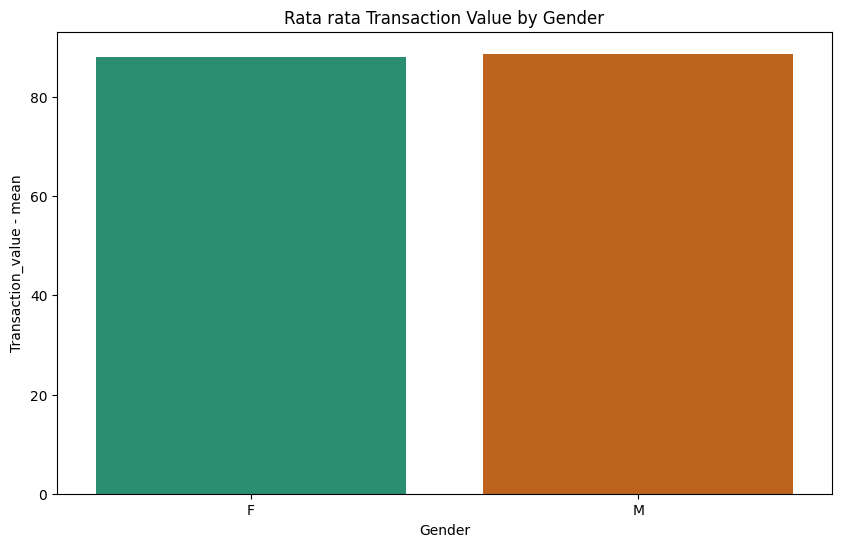

In [60]:
# contoh salah satu visualisasi

plt.figure(figsize=(10,6))

sns.barplot(
    data=gender_order,
    x="Gender",
    y="tv_mean",
    palette="Dark2"
)
plt.title("Rata rata Transaction Value by Gender")
plt.ylabel("Transaction_value - mean")
plt.xlabel("Gender")

plt.show()

In [61]:
# analisis perbedaan menggunakan ttest

male = df[df["Gender"] == "M"]["Transaction_value"]
female = df[df["Gender"] == "F"]["Transaction_value"]

t_stat, p_value = ttest_ind(male, female)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

T-Statistic: 0.511800451643045
P-value: 0.6087928097484492


#### Bagaimana pola transaksi dan pengeluaran pelanggan berdasarkan waktu (bulan)?

In [62]:
df["Month"].describe()

count    52924.000000
mean         6.652388
std          3.333364
min          1.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         12.000000
Name: Month, dtype: float64

In [63]:
monthly_order = df.groupby("Month").agg(
    transaction_count = ("Transaction_ID", "count"),
    mean_tren = ("Transaction_value", "mean"),
    median_tren = ("Transaction_value", "median"),
    total_tren = ("Transaction_value", "sum")
).reset_index().sort_values("Month")

monthly_order

,Month,transaction_count,mean_tren,median_tren,total_tren
0,1,4063,99.341516,63.49,403624.58
1,2,3284,94.646711,45.57,310819.80
2,3,4346,80.443647,34.99,349608.09
3,4,4150,96.775523,28.68,401618.42
4,5,4572,67.314834,24.64,307763.42
5,6,4193,76.575574,20.99,321081.38
6,7,5251,70.965163,16.99,372638.07
7,8,6150,65.237459,15.99,401210.37
8,9,4288,84.083116,23.98,360548.40
9,10,4164,98.386475,39.19,409681.28


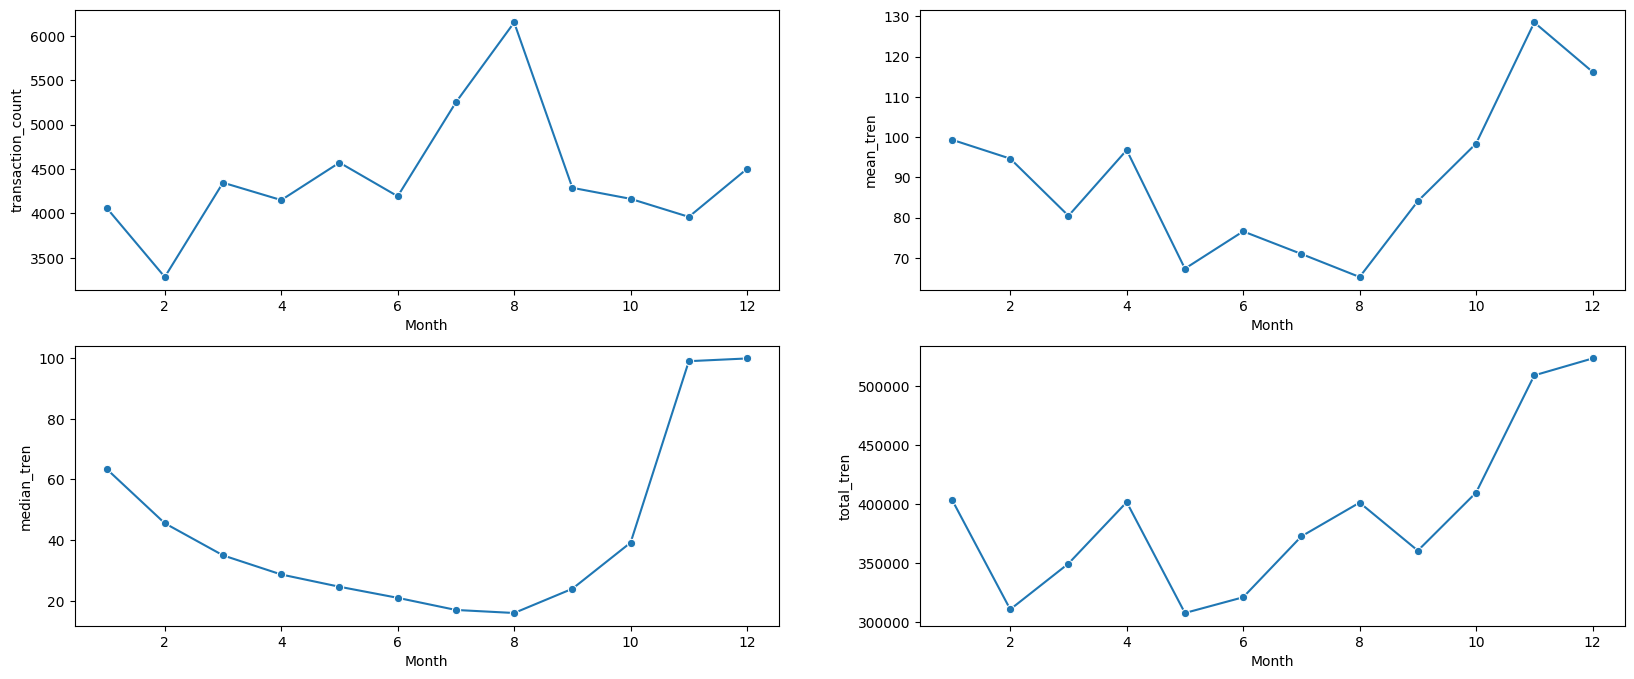

In [64]:
fig, ax= plt.subplots(2, 2, figsize=(20,8))

sns.lineplot(
    data=monthly_order,
    x="Month",
    y="transaction_count",
    marker="o",
    ax=ax[0,0]
)

sns.lineplot(
    data=monthly_order,
    x="Month",
    y="mean_tren",
    marker="o",
    ax=ax[0,1]
)

sns.lineplot(
    data=monthly_order,
    x="Month",
    y="median_tren",
    marker="o",
    ax=ax[1,0]
)

sns.lineplot(
    data=monthly_order,
    x="Month",
    y="total_tren",
    marker="o",
    ax=ax[1,1]
)

plt.show()

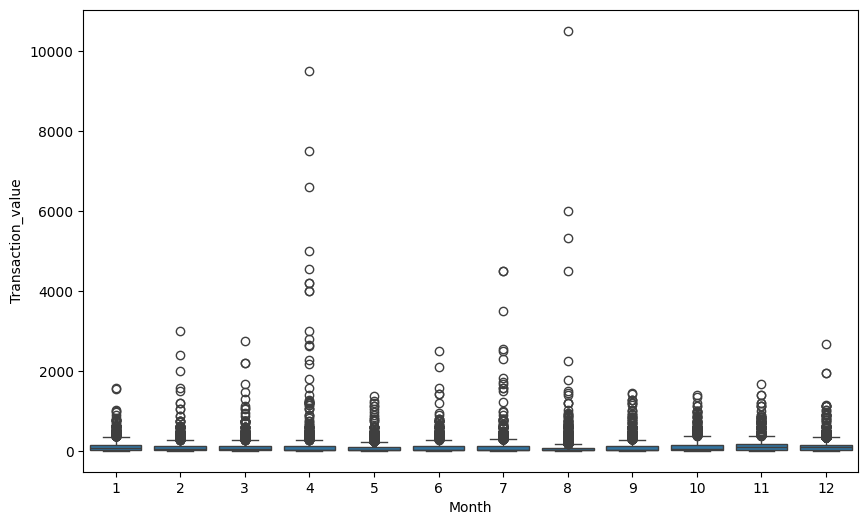

In [65]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="Month",
    y="Transaction_value"
)
plt.show()

#### Seberapa besar kontribusi biaya tambahan (Delivery_Charges dan GST) terhadap total nilai transaksi?

In [66]:
df[["Delivery_Charges", "GST"]].describe()

,Delivery_Charges,GST
count,52924.000000,52924.000000
mean,10.517630,0.137462
std,19.475613,0.045825
min,0.000000,0.050000
25%,6.000000,0.100000
50%,6.000000,0.180000
75%,6.500000,0.180000
max,521.360000,0.180000


In [ ]:
df["Base_value"] = df["Transaction_value"].copy()
df["Extra_charges"] = df["Delivery_Charges"] + df["GST"]
df["Total_value"] = df["Base_value"] + df["Extra_charges"]  # transaksi setelah terkena Delivery_Charges dan GST

In [68]:
total_base = df["Base_value"].sum()
total_delivery = df["Delivery_Charges"].sum()
total_gst = df["GST"].sum()
total_all = df["Total_value"].sum()

In [69]:
contribution = pd.DataFrame({
    "Component": ["Base Value", "Delivery Charges", "GST"],
    "Amount": [total_base, total_delivery, total_gst]
})

contribution["Percentage"] = contribution["Amount"] / total_all * 100
contribution

,Component,Amount,Percentage
0,Base Value,4670794.62,89.227471
1,Delivery Charges,556635.07,10.633552
2,GST,7275.03,0.138977


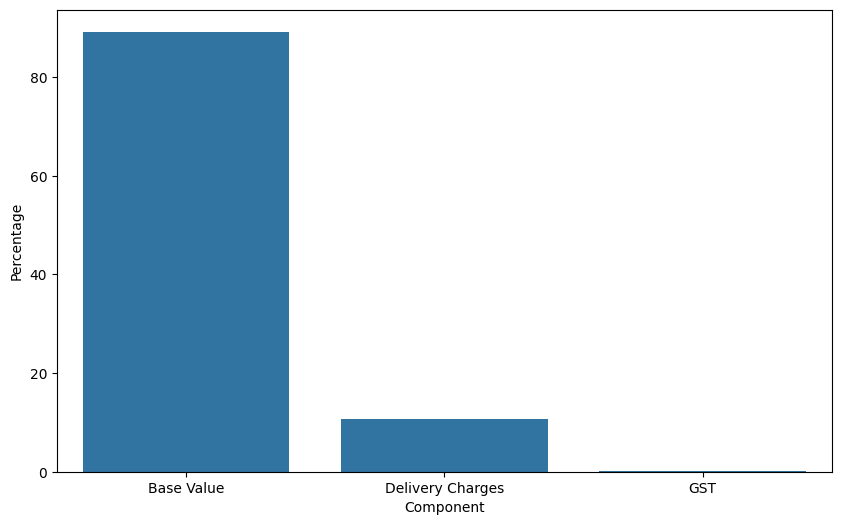

In [70]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=contribution,
    x="Component",
    y="Percentage"
)
plt.show()

In [71]:
df["Extra_pct"] = df["Extra_charges"] / df["Total_value"] * 100
df["Extra_pct"].describe()

count    52924.000000
mean        26.858531
std         23.699631
min          0.009999
25%          5.101646
50%         22.376305
75%         41.255007
max         99.111015
Name: Extra_pct, dtype: float64

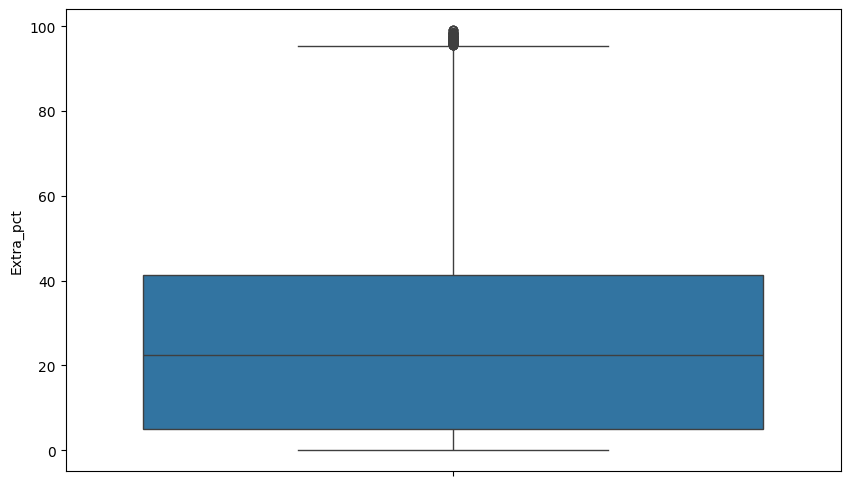

In [72]:
plt.figure(figsize=(10,6))
sns.boxplot(y=df["Extra_pct"])
plt.show()

In [73]:
df.groupby("Product_Category")["CustomerID"].nunique()

Product_Category
Accessories              150
Android                   42
Apparel                 1323
Backpacks                 75
Bags                     728
Bottles                  203
Drinkware                919
Fun                      118
Gift Cards                77
Google                    89
Headgear                 425
Housewares               107
Lifestyle                817
More Bags                 37
Nest                     516
Nest-Canada              205
Nest-USA                1260
Notebooks & Journals     383
Office                  1103
Waze                     309
Name: CustomerID, dtype: int64

In [74]:
df["Product_Category"].value_counts()

Product_Category
Apparel                 18126
Nest-USA                14013
Office                   6513
Drinkware                3483
Lifestyle                3092
Nest                     2198
Bags                     1882
Headgear                  771
Notebooks & Journals      749
Waze                      554
Nest-Canada               317
Bottles                   268
Accessories               234
Fun                       160
Gift Cards                159
Housewares                122
Google                    105
Backpacks                  89
More Bags                  46
Android                    43
Name: count, dtype: int64

In [ ]:
# df.to_csv("shopping_sales.csv", index=False)

### Forecasting

In [78]:
df["Month_dt"] = df["Transaction_Date"].dt.month

In [79]:
monthly_sales = df.groupby("Month_dt")["Transaction_value"].sum().reset_index()

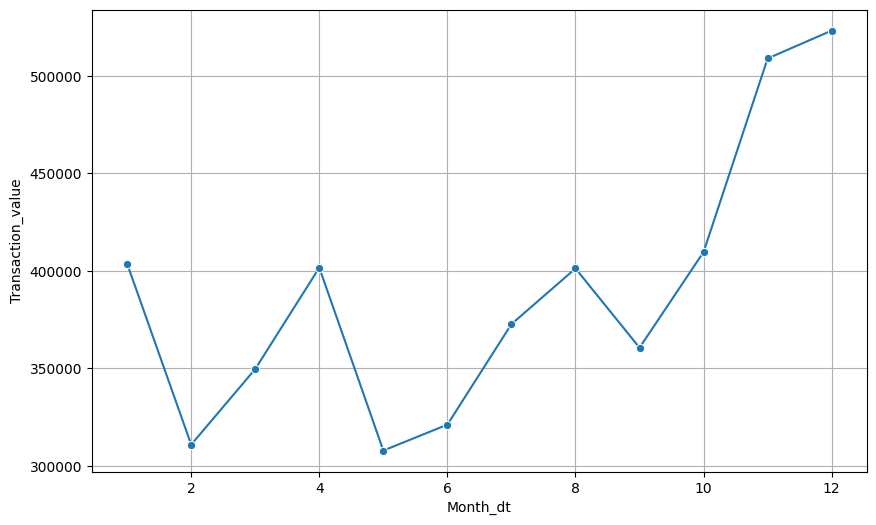

In [80]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_sales,
    x="Month_dt",
    y="Transaction_value",
    marker="o"
)
plt.grid()
plt.show()

In [81]:
train = monthly_sales.iloc[:-2]
test = monthly_sales.iloc[-2:]

In [82]:
print(len(train), len(test))

10 2


In [83]:
from statsmodels.tsa.holtwinters import Holt

model = Holt(train["Transaction_value"]).fit()

In [84]:
forecast = model.forecast(len(test))

In [85]:
compare = test.copy()
compare["forecast"] = forecast.values
compare

,Month_dt,Transaction_value,forecast
10,11,508942.62,416513.370475
11,12,523258.19,431751.398663


In [86]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    compare["Transaction_value"],
    compare["forecast"]
)

print(f"MAPE: {mape:.2%}")

MAPE: 17.82%


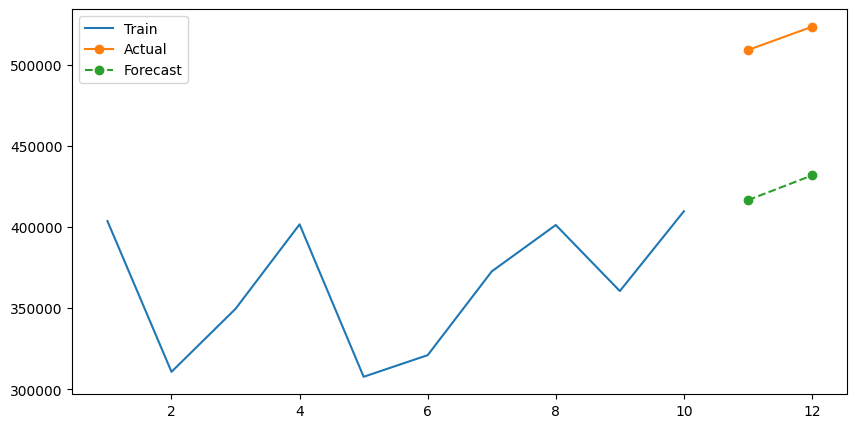

In [87]:
plt.figure(figsize=(10,5))
plt.plot(train["Month_dt"], train["Transaction_value"], label="Train")
plt.plot(test["Month_dt"], test["Transaction_value"], label="Actual", marker="o")
plt.plot(test["Month_dt"], forecast, label="Forecast", marker="o", linestyle="--")

plt.legend()
plt.show()